## RoboArena Hacking 2
- Ok here i just want to do a bunch of renders!
- Ok i would like to include `npz` data but maybe just start with prompts and videos

```source /home/stephen/robots/openpi/.venv/bin/activate```

In [1]:
from huggingface_hub import HfApi, hf_hub_download, snapshot_download
from collections import defaultdict
import os
import re
import yaml
import glob
import numpy as np
import cv2  # pip install opencv-python
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from openpi.training import config as _config
from openpi.policies import policy_config
from openpi.shared import download
from openpi_client import image_tools

## Helper Functions

In [2]:
def find_pi05_sessions(base_dir):
    """Find all sessions that contain a pi05 policy."""
    sessions = []
    for sid in sorted(os.listdir(base_dir)):
        session_path = os.path.join(base_dir, sid)
        if not os.path.isdir(session_path):
            continue
        for entry in os.listdir(session_path):
            if os.path.isdir(os.path.join(session_path, entry)) and "pi05" in entry.lower():
                sessions.append((sid, entry))
                break
    return sessions


def load_videos(policy_dir):
    """Load videos from a policy directory, returning {camera_type: frames_array}."""
    videos = {}
    for mp4 in glob.glob(os.path.join(policy_dir, "*.mp4")):
        fname = os.path.splitext(os.path.basename(mp4))[0]
        # Extract camera type from filename like "pi05_droid_2025-..._video_wrist"
        if "wrist" in fname:
            cam_key = "wrist"
        elif "right" in fname:
            cam_key = "right"
        elif "left" in fname:
            cam_key = "left"
        else:
            cam_key = fname  # fallback
        cap = cv2.VideoCapture(mp4)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()
        videos[cam_key] = np.stack(frames) if frames else np.empty((0,))
    return videos

## Load RoboArena Session

In [3]:
from openpi_client import image_tools
from matplotlib.animation import FuncAnimation, FFMpegWriter
save_dir='/home/stephen/robots/mar_1_1'

In [4]:
def update(t):
    plt.clf()

    step_data = npz_data[t]
    if "right" in videos and videos["right"].ndim == 4 and t < len(videos["right"]):
        exterior_img = videos["right"][t]  # (H, W, 3) uint8
    elif "left" in videos and videos["left"].ndim == 4 and t < len(videos["left"]):
        exterior_img = videos["left"][t]
    else:
        print(f"No exterior camera found. Available: {list(videos.keys())}")
        # continue
    
    if "wrist" in videos and videos["wrist"].ndim == 4 and t < len(videos["wrist"]):
        wrist_img = videos["wrist"][t]
    else:
        print(f"No wrist camera found. Available: {list(videos.keys())}")
        # continue
    
    # obs = {
    #     "observation/exterior_image_1_left": image_tools.resize_with_pad(exterior_img, 224, 224),
    #     "observation/wrist_image_left": image_tools.resize_with_pad(wrist_img, 224, 224),
    #     "observation/joint_position": np.array(step_data["joint_position"], dtype=np.float64),
    #     "observation/gripper_position": np.array(step_data["gripper_position"], dtype=np.float64),
    #     "prompt": language_instruction,
    # }
    

    fig=plt.figure(0, (12, 8))
    ax=fig.add_subplot(1,2,1)
    plt.imshow(exterior_img)
    plt.title(meta['language_instruction'])
    
    ax=fig.add_subplot(1,2,2)
    plt.imshow(wrist_img)
    plt.xlabel(meta['evaluator_name'])
    plt.title(SESSION_ID)

In [5]:
ROBOARENA_DIR = "/home/stephen/robots/openpi/src/openpi/roboarena_pi05/evaluation_sessions"
sessions = find_pi05_sessions(ROBOARENA_DIR)

# session_count=300 #Pick a session
# , pi05_dir_name = sessions[session_count]
# session_path = os.path.join(ROBOARENA_DIR, SESSION_ID)


  0%|                                                                                                            | 0/564 [00:00<?, ?it/s]/tmp/ipykernel_395222/3725500585.py:28: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (12, 8))
  0%|▏                                                                                                | 1/564 [01:07<10:36:52, 67.87s/it]/tmp/ipykernel_395222/1916476127.py:17: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig = plt.figure(0, (12, 8))
/tmp/ipykernel_395222/3725500585.py:28: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (12, 8))
  0%|▎                                                                                                | 2/564 [02:15<10:35:07, 67.81s/it]/tmp/ipykernel_395222/1916476127.py:17: UserWarning: Ignoring specified arguments in this

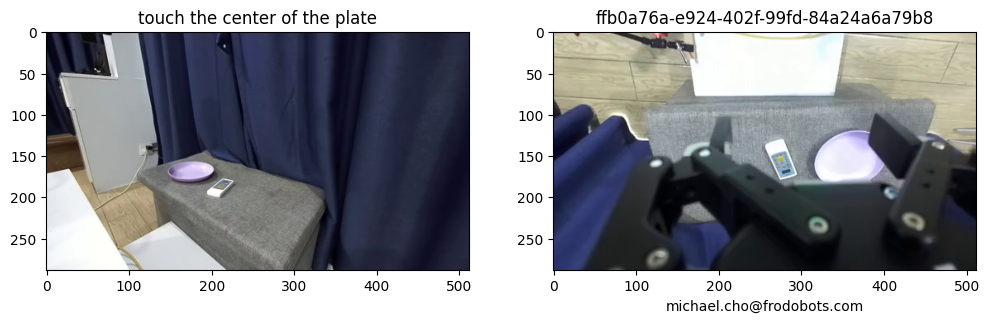

In [6]:
#Big lerp
for session_count in tqdm(range(len(sessions))):

    SESSION_ID, pi05_dir_name = sessions[session_count]
    session_path = os.path.join(ROBOARENA_DIR, SESSION_ID)

    # Load metadata
    meta_path = os.path.join(session_path, "metadata.yaml")
    with open(meta_path) as f:
        meta = yaml.safe_load(f)
    language_instruction = meta["language_instruction"]

    pi05_dir = os.path.join(session_path, pi05_dir_name)
    videos = load_videos(pi05_dir)
    npz_data = np.load(glob.glob(pi05_dir+"/*.npz")[0], allow_pickle=True)["data"]

    fig = plt.figure(0, (12, 8))
    anim = FuncAnimation(fig, update, frames=np.arange(0, len(npz_data)-1, 1))
    anim.save(save_dir+"/" + SESSION_ID + ".mp4", writer=FFMpegWriter(fps=30))

In [4]:
SESSION_ID

'84753bcf-b8fe-41e7-b084-1e034b48c743'

In [5]:
meta

{'evaluation_location': 'Stanford',
 'evaluator_name': 'skunda@stanford.edu',
 'session_creation_timestamp': '2025-07-28T18:39:30.371957Z',
 'session_completion_timestamp': '2025-07-28T18:46:30.702588Z',
 'language_instruction': 'put banana in drawer ',
 'preference': 'B',
 'longform_feedback': 'B managed to place the banana on top of the drawer but A dropped the banana before it reached to the drawer',
 'policies': {'B': {'policy_name': 'pi05_droid',
   'binary_success': 0,
   'partial_success': 0.75,
   'duration': 399},
  'A': {'policy_name': 'pi0_droid',
   'binary_success': 0,
   'partial_success': 0.5,
   'duration': 399}}}

In [6]:
videos.keys()

dict_keys(['wrist', 'right'])

In [7]:
videos['wrist'].shape, videos['right'].shape

((401, 288, 512, 3), (401, 288, 512, 3))

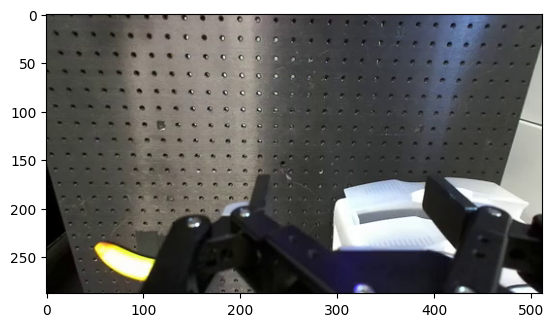

In [8]:
plt.imshow(videos['wrist'][0, :])

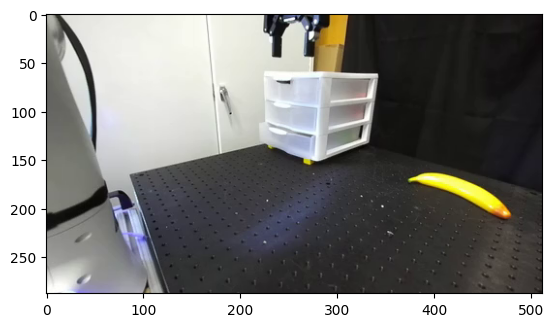

In [9]:
plt.imshow(videos['right'][0, :])

In [10]:
npz_data[0]

{'cartesian_position': [0.3708862364292145,
  -0.0007703459705226123,
  0.4892633855342865,
  -3.126329151277612,
  -0.006988664374402598,
  0.016982439728133885],
 'joint_position': [-0.025134773924946785,
  -0.5922703742980957,
  0.016842398792505264,
  -2.4908504486083984,
  0.02631278522312641,
  1.9050960540771484,
  -0.03671929985284805],
 'gripper_position': [0.0],
 'action': [0.13935640454292297,
  0.20338959991931915,
  -0.1310155838727951,
  0.1484198123216629,
  -0.032078348100185394,
  0.060021765530109406,
  -0.3757030963897705,
  0.0]}

In [11]:
# fig=plt.figure(0, (12, 6))
# for i in range(6):
#     fig.add_subplot(2,4,i+1)
#     plt.plot([npz_data[j]['cartesian_position'][i] for j in range(len(npz_data))])

In [12]:
# fig=plt.figure(0, (12, 6))
# for i in range(7):
#     fig.add_subplot(2,4,i+1)
#     plt.plot(10*np.diff([npz_data[j]['joint_position'][i] for j in range(len(npz_data))]))
#     plt.plot([npz_data[j]['action'][i] for j in range(len(npz_data))])

In [13]:
# fig=plt.figure(0, (12, 6))
# for i in range(8):
#     fig.add_subplot(2,4,i+1)
#     plt.plot([npz_data[j]['action'][i] for j in range(len(npz_data))])

## Load Model

In [14]:
#Droid finetuned pi05 model
config = _config.get_config("pi05_droid")
checkpoint_dir = download.maybe_download("gs://openpi-assets/checkpoints/pi05_droid")
policy = policy_config.create_trained_policy(config, checkpoint_dir)

## Format inputs for pi05_droid model

In [15]:
from openpi_client import image_tools
from PIL import Image

In [16]:
t=100

In [17]:
step_data = npz_data[t]
if "right" in videos and videos["right"].ndim == 4 and t < len(videos["right"]):
    exterior_img = videos["right"][t]  # (H, W, 3) uint8
elif "left" in videos and videos["left"].ndim == 4 and t < len(videos["left"]):
    exterior_img = videos["left"][t]
else:
    print(f"No exterior camera found. Available: {list(videos.keys())}")

if "wrist" in videos and videos["wrist"].ndim == 4 and t < len(videos["wrist"]):
    wrist_img = videos["wrist"][t]
else:
    print(f"No wrist camera found. Available: {list(videos.keys())}")

#Resize with pad comes from: 
# https://github.com/Physical-Intelligence/openpi/blob/981483dca0fd9acba698fea00aa6e52d56a66c58/examples/droid/main.py#L120
obs = {
    "observation/exterior_image_1_left": image_tools.resize_with_pad(exterior_img, 224, 224),
    "observation/wrist_image_left": image_tools.resize_with_pad(wrist_img, 224, 224),
    "observation/joint_position": np.array(step_data["joint_position"], dtype=np.float64),
    "observation/gripper_position": np.array(step_data["gripper_position"], dtype=np.float64),
    "prompt": language_instruction,
}

# obs = {
#     "observation/exterior_image_1_left": np.array(Image.fromarray(exterior_img).resize((224, 224), resample=Image.LANCZOS)),
#     "observation/wrist_image_left": np.array(Image.fromarray(wrist_img).resize((224, 224), resample=Image.LANCZOS)),
#     "observation/joint_position": np.array(step_data["joint_position"], dtype=np.float64),
#     "observation/gripper_position": np.array(step_data["gripper_position"], dtype=np.float64),
#     "prompt": language_instruction,
# }


In [18]:
action_chunks=[] 
for i in tqdm(range(10)):
    result = policy.infer(obs)
    action_chunk = result["actions"]
    action_chunks.append(action_chunk)

action_chunks=np.array(action_chunks)

100%|█████████████████████████████████████████████████████████| 10/10 [00:34<00:00,  3.43s/it]


In [19]:
action_chunks.shape

(10, 15, 8)

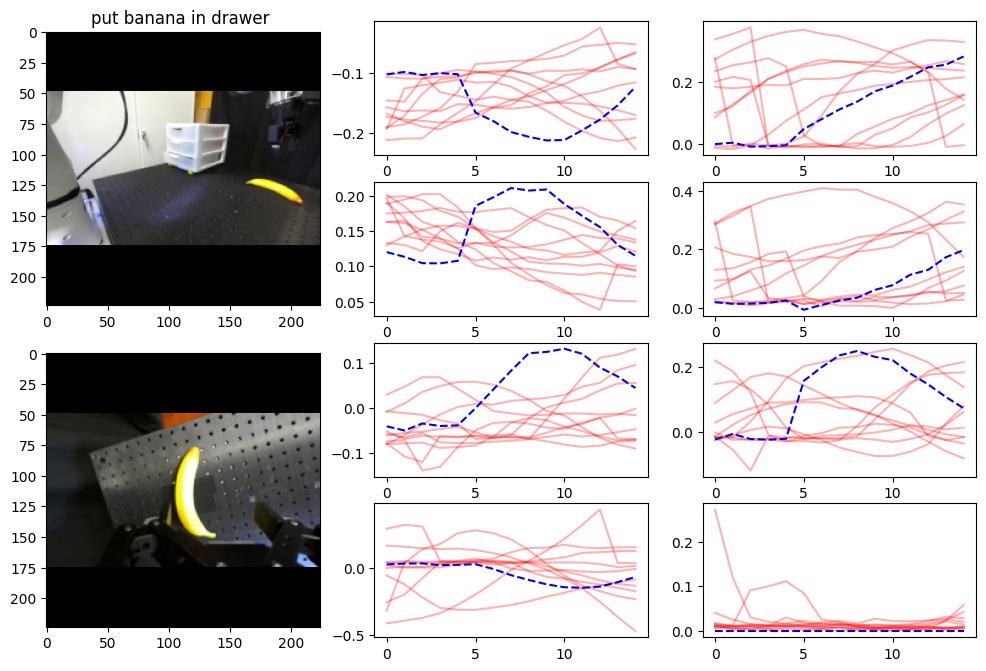

In [20]:
fig=plt.figure(0, (12, 8))
gs = fig.add_gridspec(4, 3)

ax=fig.add_subplot(gs[:2, 0])
plt.imshow(obs["observation/exterior_image_1_left"])
plt.title(meta['language_instruction'])

ax=fig.add_subplot(gs[2:, 0])
plt.imshow(obs["observation/wrist_image_left"])
# plt.xlabel(meta['evaluator_name'])

locs=[(0, 1), (0, 2), (1, 1), (1, 2), (2, 1), (2, 2), (3, 1), (3, 2)]
for i in range(8):
    ax=fig.add_subplot(gs[*locs[i]])
    for j in range(action_chunks.shape[0]): plt.plot(action_chunks[j, :, i], c='r', alpha=0.3)
    plt.plot([npz_data[t+j]['action'][i] for j in range(15)], 'b--')

In [21]:
action_mean=np.mean(action_chunks, 0)
action_std=np.std(action_chunks, 0)

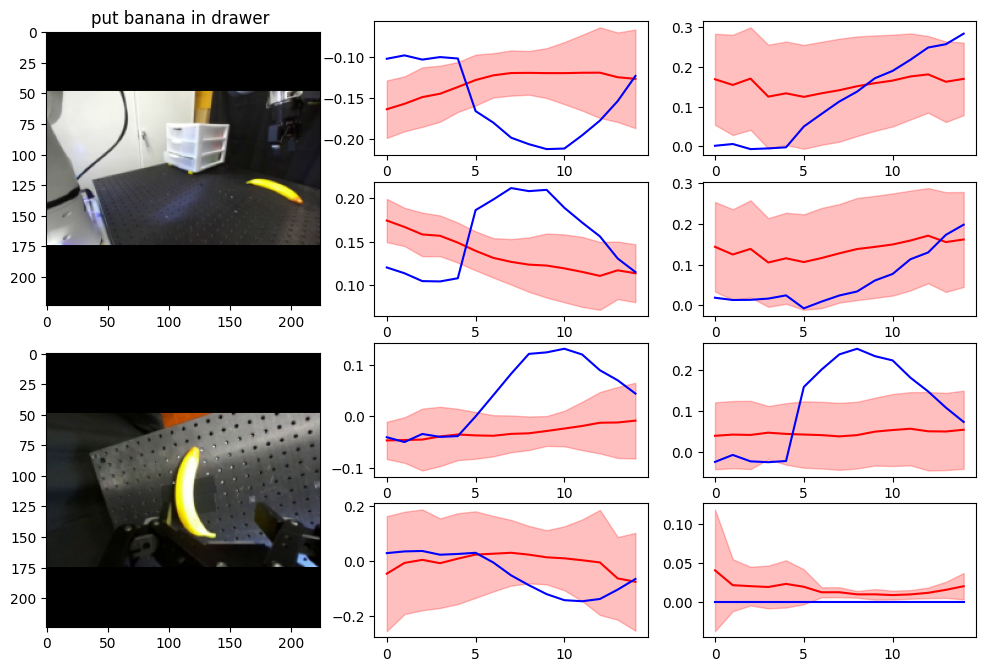

In [22]:
fig=plt.figure(0, (12, 8))
gs = fig.add_gridspec(4, 3)

ax=fig.add_subplot(gs[:2, 0])
plt.imshow(obs["observation/exterior_image_1_left"])
plt.title(meta['language_instruction'])

ax=fig.add_subplot(gs[2:, 0])
plt.imshow(obs["observation/wrist_image_left"])
# plt.xlabel(meta['evaluator_name'])

locs=[(0, 1), (0, 2), (1, 1), (1, 2), (2, 1), (2, 2), (3, 1), (3, 2)]
for i in range(8):
    ax=fig.add_subplot(gs[*locs[i]])
    plt.plot(action_mean[:,i], c='r')
    ax.fill_between(np.arange(15), action_mean[:,i] - action_std[:,i], action_mean[:,i] + action_std[:,i], alpha=0.25, color='r')
    plt.plot([npz_data[t+j]['action'][i] for j in range(15)], c='b')
    # plt.ylim([-1, 1])
# plt.xlabel(meta['evaluator_name'])